In [1]:
# Install required dependencies
!pip install pandas numpy yfinance xgboost scikit-learn matplotlib

In [2]:
import warnings

import numpy as np
import pandas as pd
import yfinance as yf
from xgboost import XGBClassifier


# Suppress non-critical warnings for cleaner output
warnings.filterwarnings("ignore")


# ============================================================
# 1. DATA COLLECTION
# ============================================================

print("Fetching Nifty 50 ETF Intraday Data...")

# Fetch the tradable Nifty 50 ETF for real volume data
df = yf.download(
    "NIFTYBEES.NS",
    interval="1h",
    period="730d"
)

# Flatten the columns if yfinance returned a MultiIndex table
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

df.dropna(inplace=True)


# ============================================================
# 2. TECHNICAL INDICATORS & LIQUIDITY PROXIES
# ============================================================

print("Calculating Technical Indicators and Liquidity Proxies...")


# ------------------------------------------------------------
# 2.1 Liquidity Proxy: Relative Volume
# ------------------------------------------------------------

df["Volume_MA20"] = df["Volume"].rolling(window=20).mean()

# Safe calculation to prevent divide-by-zero
df["Relative_Volume"] = np.where(
    df["Volume_MA20"] == 0,
    1,
    df["Volume"] / df["Volume_MA20"]
)


# ------------------------------------------------------------
# 2.2 Volatility Proxy: Average True Range (ATR)
# ------------------------------------------------------------

df["High_Low"] = df["High"] - df["Low"]

df["High_PrevClose"] = np.abs(
    df["High"] - df["Close"].shift(1)
)

df["Low_PrevClose"] = np.abs(
    df["Low"] - df["Close"].shift(1)
)

df["True_Range"] = df[
    ["High_Low", "High_PrevClose", "Low_PrevClose"]
].max(axis=1)

df["ATR"] = df["True_Range"].rolling(window=14).mean()


# ------------------------------------------------------------
# 2.3 Momentum Indicator: RSI
# ------------------------------------------------------------

delta = df["Close"].diff()

gain = (
    delta.where(delta > 0, 0)
    .rolling(window=14)
    .mean()
)

loss = (
    -delta.where(delta < 0, 0)
    .rolling(window=14)
    .mean()
)

rs = gain / loss

df["RSI"] = 100 - (100 / (1 + rs))


# ============================================================
# 3. TARGET VARIABLE
# ============================================================

df["Next_Close"] = df["Close"].shift(-1)

df["Target"] = np.where(
    df["Next_Close"] > df["Close"],
    1,
    0
)


# Remove rows containing NaN values created by indicators
df.dropna(inplace=True)

print(f"Total trading bars ready for ML: {df.shape[0]}")


# ============================================================
# 4. MACHINE LEARNING MODEL
# ============================================================

print("\nTraining the XGBoost Machine Learning Model...")


# Define features and target
X = df[
    [
        "Open",
        "High",
        "Low",
        "Volume",
        "Relative_Volume",
        "ATR",
        "RSI",
    ]
]

y = df["Target"]


# ------------------------------------------------------------
# 4.1 Chronological Train-Test Split
# ------------------------------------------------------------

split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]


# ------------------------------------------------------------
# 4.2 Initialize and Train XGBoost
# ------------------------------------------------------------

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)


# ============================================================
# 5. PROBABILITY GENERATION
# ============================================================

print("Model Trained. Generating Probabilities...")

df["Prob_UP"] = model.predict_proba(X)[:, 1]


# ============================================================
# 6. 4-ACTION DECISION CONTROLLER
# ============================================================

print("Executing the 4-Action Decision Controller...")


# Decision Controller thresholds
CONFIDENCE_THRESHOLD = 0.55
LIQUIDITY_THRESHOLD = 1.0


# Extract model probability and liquidity values
prob_up = df["Prob_UP"]
liquidity = df["Relative_Volume"]


# Default action for every trading bar
action = np.full(
    len(df),
    "WAIT",
    dtype=object
)

signal = np.zeros(len(df))


# ------------------------------------------------------------
# 6.1 BUY LOGIC
# ------------------------------------------------------------

buy_cond = (
    (prob_up > CONFIDENCE_THRESHOLD)
    & (liquidity >= LIQUIDITY_THRESHOLD)
)

action[buy_cond] = "BUY"
signal[buy_cond] = 1.0


# ------------------------------------------------------------
# 6.2 SELL LOGIC
# ------------------------------------------------------------

sell_cond = (
    (prob_up < (1 - CONFIDENCE_THRESHOLD))
    & (liquidity >= LIQUIDITY_THRESHOLD)
)

action[sell_cond] = "SELL"
signal[sell_cond] = -1.0


# ------------------------------------------------------------
# 6.3 REDUCE SIZE LOGIC
# ------------------------------------------------------------

reduce_cond = (
    (
        (prob_up > CONFIDENCE_THRESHOLD)
        | (prob_up < (1 - CONFIDENCE_THRESHOLD))
    )
    & (liquidity < LIQUIDITY_THRESHOLD)
)

action[reduce_cond] = "REDUCE SIZE"

signal[reduce_cond] = np.where(
    prob_up[reduce_cond] > 0.5,
    0.5,
    -0.5
)


# Store controller decisions
df["Action"] = action
df["Signal"] = signal


# ============================================================
# 7. CONTROLLER SUMMARY
# ============================================================

print("\n--- Model & Controller Complete ---")
print("Total Decisions Generated by the Controller:")
print(df["Action"].value_counts())

Fetching Nifty 50 ETF Intraday Data...


[*********************100%***********************]  1 of 1 completed

Calculating Technical Indicators and Liquidity Proxies...
Total trading bars ready for ML: 5024

Training the XGBoost Machine Learning Model...
Model Trained. Generating Probabilities...
Executing the 4-Action Decision Controller...

--- Model & Controller Complete ---
Total Decisions Generated by the Controller:
Action
WAIT           2926
REDUCE SIZE    1100
BUY             773
SELL            225
Name: count, dtype: int64


In [3]:
import warnings

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier


# Suppress non-critical warnings for cleaner output
warnings.filterwarnings("ignore")


# ============================================================
# 1. TRAIN THE XGBOOST MACHINE LEARNING MODEL
# ============================================================

print("Training the XGBoost Machine Learning Model...")


# Define features (X) and target variable (y)
# 'Close' and 'Target' are excluded from the feature set
# to prevent the model from using the target information directly.
X = df[
    [
        "Open",
        "High",
        "Low",
        "Volume",
        "Relative_Volume",
        "ATR",
        "RSI",
    ]
]

y = df["Target"]


# ------------------------------------------------------------
# 1.1 Chronological Train-Test Split
# ------------------------------------------------------------

split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]


# ------------------------------------------------------------
# 1.2 Initialize and Train the XGBoost Model
# ------------------------------------------------------------

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)


# ============================================================
# 2. GENERATE MODEL PROBABILITIES
# ============================================================

print("Model Trained. Generating Probabilities...")


# Extract the probability of the next price movement being UP.
# Column index 1 corresponds to the positive class (1).
df["Prob_UP"] = model.predict_proba(X)[:, 1]


# ============================================================
# 3. 4-ACTION DECISION CONTROLLER
# ============================================================

print("Executing the 4-Action Decision Controller...")


# Decision Controller thresholds
CONFIDENCE_THRESHOLD = 0.55  # Model must be > 55% confident
LIQUIDITY_THRESHOLD = 1.0    # Volume must be >= 20-period average


# Initialize Signal and Action columns
df["Signal"] = 0.0
df["Action"] = "WAIT"


# ============================================================
# 4. APPLY DECISION CONTROLLER LOGIC
# ============================================================

for i in range(len(df)):

    prob_up = df["Prob_UP"].iloc[i]
    liquidity = df["Relative_Volume"].iloc[i]


    # --------------------------------------------------------
    # BUY LOGIC
    # High confidence in upward movement + high liquidity
    # --------------------------------------------------------

    if (
        prob_up > CONFIDENCE_THRESHOLD
        and liquidity >= LIQUIDITY_THRESHOLD
    ):
        df["Signal"].iloc[i] = 1.0
        df["Action"].iloc[i] = "BUY"


    # --------------------------------------------------------
    # SELL LOGIC
    # High confidence in downward movement + high liquidity
    # --------------------------------------------------------

    elif (
        prob_up < (1 - CONFIDENCE_THRESHOLD)
        and liquidity >= LIQUIDITY_THRESHOLD
    ):
        df["Signal"].iloc[i] = -1.0
        df["Action"].iloc[i] = "SELL"


    # --------------------------------------------------------
    # REDUCE SIZE LOGIC
    # High confidence but low liquidity
    # --------------------------------------------------------

    elif (
        (
            prob_up > CONFIDENCE_THRESHOLD
            or prob_up < (1 - CONFIDENCE_THRESHOLD)
        )
        and liquidity < LIQUIDITY_THRESHOLD
    ):
        # Take the trade with half the normal position size
        # to account for increased execution friction.
        df["Signal"].iloc[i] = (
            0.5 if prob_up > 0.5 else -0.5
        )

        df["Action"].iloc[i] = "REDUCE SIZE"


    # --------------------------------------------------------
    # WAIT LOGIC
    # All remaining cases retain the default WAIT / 0.0 state
    # --------------------------------------------------------


# ============================================================
# 5. CONTROLLER SUMMARY
# ============================================================

print("\n--- Model & Controller Complete ---")
print("Total Decisions Generated by the Controller:")
print(df["Action"].value_counts())

Training the XGBoost Machine Learning Model...
Model Trained. Generating Probabilities...
Executing the 4-Action Decision Controller...

--- Model & Controller Complete ---
Total Decisions Generated by the Controller:
Action
WAIT           2926
REDUCE SIZE    1100
BUY             773
SELL            225
Name: count, dtype: int64


In [4]:
import numpy as np
import pandas as pd


# ============================================================
# 1. WALK-FORWARD BACKTEST SETUP
# ============================================================

print("Running Walk-Forward Backtest with Transaction Costs...")


# Base market return (15-minute bar-to-bar)
df["Market_Return"] = df["Close"].pct_change()
df.fillna(0, inplace=True)


# Transaction cost / slippage assumption: 0.05% per trade
TC = 0.0005


# ============================================================
# 2. STRATEGY 1: BUY & HOLD
# ============================================================

df["B&H_Equity"] = (
    1 + df["Market_Return"]
).cumprod()


# ============================================================
# 3. STRATEGY 2: ML — ALWAYS TRADE
# ============================================================

# The AI trades 100% position size on every bar,
# following only the predicted probability.
df["Always_Trade_Signal"] = np.where(
    df["Prob_UP"] > 0.5,
    1.0,
    -1.0
)

df["Always_Trade_Return"] = (
    df["Always_Trade_Signal"].shift(1)
    * df["Market_Return"]
)


# Apply transaction costs whenever the signal changes.
at_trades = (
    df["Always_Trade_Signal"].diff() != 0
)

df["Always_Trade_Return"] = np.where(
    at_trades,
    df["Always_Trade_Return"] - TC,
    df["Always_Trade_Return"]
)

df["Always_Trade_Equity"] = (
    1 + df["Always_Trade_Return"]
).cumprod()


# ============================================================
# 4. STRATEGY 3: ML — FULL DECISION CONTROLLER
# ============================================================

df["System_Return"] = (
    df["Signal"].shift(1)
    * df["Market_Return"]
)


# Apply transaction costs dynamically.
# Position-size changes incur proportionally adjusted friction.
sys_trades = (
    df["Signal"].diff() != 0
)

df["System_Return"] = np.where(
    sys_trades,
    df["System_Return"]
    - (
        TC
        * np.abs(df["Signal"].diff())
    ),
    df["System_Return"]
)

df["System_Equity"] = (
    1 + df["System_Return"]
).cumprod()


# ============================================================
# 5. EVALUATION METRICS
# ============================================================

print("Calculating Final Evaluation Metrics...\n")


# ------------------------------------------------------------
# 5.1 Maximum Drawdown
# ------------------------------------------------------------

def calculate_max_drawdown(equity_curve):
    """Calculate the maximum drawdown of an equity curve."""

    roll_max = equity_curve.cummax()
    drawdown = equity_curve / roll_max - 1.0

    return drawdown.min()


# ------------------------------------------------------------
# 5.2 Annualized Sharpe Ratio
# ------------------------------------------------------------

def calculate_sharpe(returns):
    """Calculate annualized Sharpe ratio."""

    if returns.std() == 0:
        return 0

    return (
        returns.mean() / returns.std()
    ) * np.sqrt(252 * 25)


# ============================================================
# 6. FINAL PERFORMANCE METRICS
# ============================================================

metrics = {
    "Strategy": [
        "Buy & Hold",
        "ML: Always Trade",
        "ML: Full Controller"
    ],

    "Total Return (%)": [
        (df["B&H_Equity"].iloc[-1] - 1) * 100,
        (df["Always_Trade_Equity"].iloc[-1] - 1) * 100,
        (df["System_Equity"].iloc[-1] - 1) * 100
    ],

    "Max Drawdown (%)": [
        calculate_max_drawdown(
            df["B&H_Equity"]
        ) * 100,

        calculate_max_drawdown(
            df["Always_Trade_Equity"]
        ) * 100,

        calculate_max_drawdown(
            df["System_Equity"]
        ) * 100
    ],

    "Sharpe Ratio": [
        calculate_sharpe(
            df["Market_Return"]
        ),

        calculate_sharpe(
            df["Always_Trade_Return"]
        ),

        calculate_sharpe(
            df["System_Return"]
        )
    ]
}


# ============================================================
# 7. CAPSTONE EVALUATION TABLE
# ============================================================

metrics_df = pd.DataFrame(metrics)

print("================ CAPSTONE EVALUATION TABLE ================")
print(
    metrics_df
    .round(2)
    .to_string(index=False)
)
print("===========================================================")

Running Walk-Forward Backtest with Transaction Costs...
Calculating Final Evaluation Metrics...

================ CAPSTONE EVALUATION TABLE ================
           Strategy  Total Return (%)  Max Drawdown (%)  Sharpe Ratio
         Buy & Hold             21.62            -15.97          1.19
   ML: Always Trade            271.91            -13.73          7.36
ML: Full Controller             36.27            -10.24          3.76


In [5]:
import numpy as np


# ============================================================
# 1. ISOLATE THE OUT-OF-SAMPLE TEST DATA
# ============================================================

# Select the final 20% of the dataset as the unseen test set.
split_idx = int(len(df) * 0.8)

test_df = df.iloc[split_idx:].copy()

total_periods = len(test_df)


# ============================================================
# 2. ALWAYS TRADE MODEL — TEST SET METRICS
# ============================================================

# Total trades: count how many times the trading signal flipped.
ml_trades = (
    test_df["Always_Trade_Signal"].diff() != 0
).sum()

# The Always Trade model is continuously exposed to the market.
ml_exposure = 100.0


# ------------------------------------------------------------
# 2.1 Win Rate
# ------------------------------------------------------------

# Count winning and losing bars.
ml_winning_bars = (
    test_df["Always_Trade_Return"] > 0
).sum()

ml_losing_bars = (
    test_df["Always_Trade_Return"] < 0
).sum()

ml_win_rate = (
    ml_winning_bars
    / (ml_winning_bars + ml_losing_bars)
) * 100


# ============================================================
# 3. DECISION CONTROLLER — TEST SET METRICS
# ============================================================

# Total trades: count how many times the signal
# changed in size or direction.
controller_trades = (
    test_df["Signal"].diff() != 0
).sum()


# Market exposure: percentage of periods where
# the controller maintained a non-zero position.
controller_exposure = (
    (test_df["Signal"] != 0).sum()
    / total_periods
) * 100


# ------------------------------------------------------------
# 3.1 Win Rate
# ------------------------------------------------------------

controller_winning_bars = (
    test_df["System_Return"] > 0
).sum()

controller_losing_bars = (
    test_df["System_Return"] < 0
).sum()

controller_win_rate = (
    controller_winning_bars
    / (controller_winning_bars + controller_losing_bars)
) * 100


# ============================================================
# 4. DISPLAY TEST-SET METRICS
# ============================================================

print("=== TABLE 1: ALWAYS TRADE METRICS ===")
print(f"Total Trades: {ml_trades}")
print(f"Market Exposure: {ml_exposure:.2f}%")
print(f"Win Rate: {ml_win_rate:.2f}%\n")

print("=== TABLE 1: FULL DECISION CONTROLLER METRICS ===")
print(f"Total Trades: {controller_trades}")
print(f"Market Exposure: {controller_exposure:.2f}%")
print(f"Win Rate: {controller_win_rate:.2f}%\n")


# ============================================================
# 5. RANDOM BASELINE EXPERIMENT
# ============================================================

print("=== RESEARCH EXPERIMENT: RANDOM BASELINE TEST ===")


# Fix the random seed for reproducibility.
np.random.seed(42)

prob_trade = controller_exposure / 100.0

random_mask = np.random.choice(
    [1, 0],
    size=len(test_df),
    p=[prob_trade, 1 - prob_trade]
)


# Apply the random abstention mask to
# the Always Trade model's returns.
test_df["Random_Return"] = (
    test_df["Always_Trade_Return"]
    * random_mask
)


# Calculate cumulative return of the random baseline.
random_cumulative_return = (
    1 + test_df["Random_Return"]
).prod() - 1


# ============================================================
# 6. COMPARE TEST-SET RETURNS
# ============================================================

at_return = (
    test_df["Always_Trade_Equity"].iloc[-1]
    / test_df["Always_Trade_Equity"].iloc[0]
    - 1
) * 100

sys_return = (
    test_df["System_Equity"].iloc[-1]
    / test_df["System_Equity"].iloc[0]
    - 1
) * 100


# ============================================================
# 7. RANDOM BASELINE COMPARISON
# ============================================================

print(f"Always Trade Return:       {at_return:.2f}%")
print(
    f"Random Abstention Return:  "
    f"{random_cumulative_return * 100:.2f}%"
)
print(
    f"Decision Controller Return:"
    f"{sys_return:.2f}%"
)

=== TABLE 1: ALWAYS TRADE METRICS ===
Total Trades: 311
Market Exposure: 100.00%
Win Rate: 48.29%

=== TABLE 1: FULL DECISION CONTROLLER METRICS ===
Total Trades: 442
Market Exposure: 39.70%
Win Rate: 31.29%

=== RESEARCH EXPERIMENT: RANDOM BASELINE TEST ===
Always Trade Return:       -9.15%
Random Abstention Return:  -3.12%
Decision Controller Return:-7.88%


Generating Figure 1: Feature Importance Bar Chart...


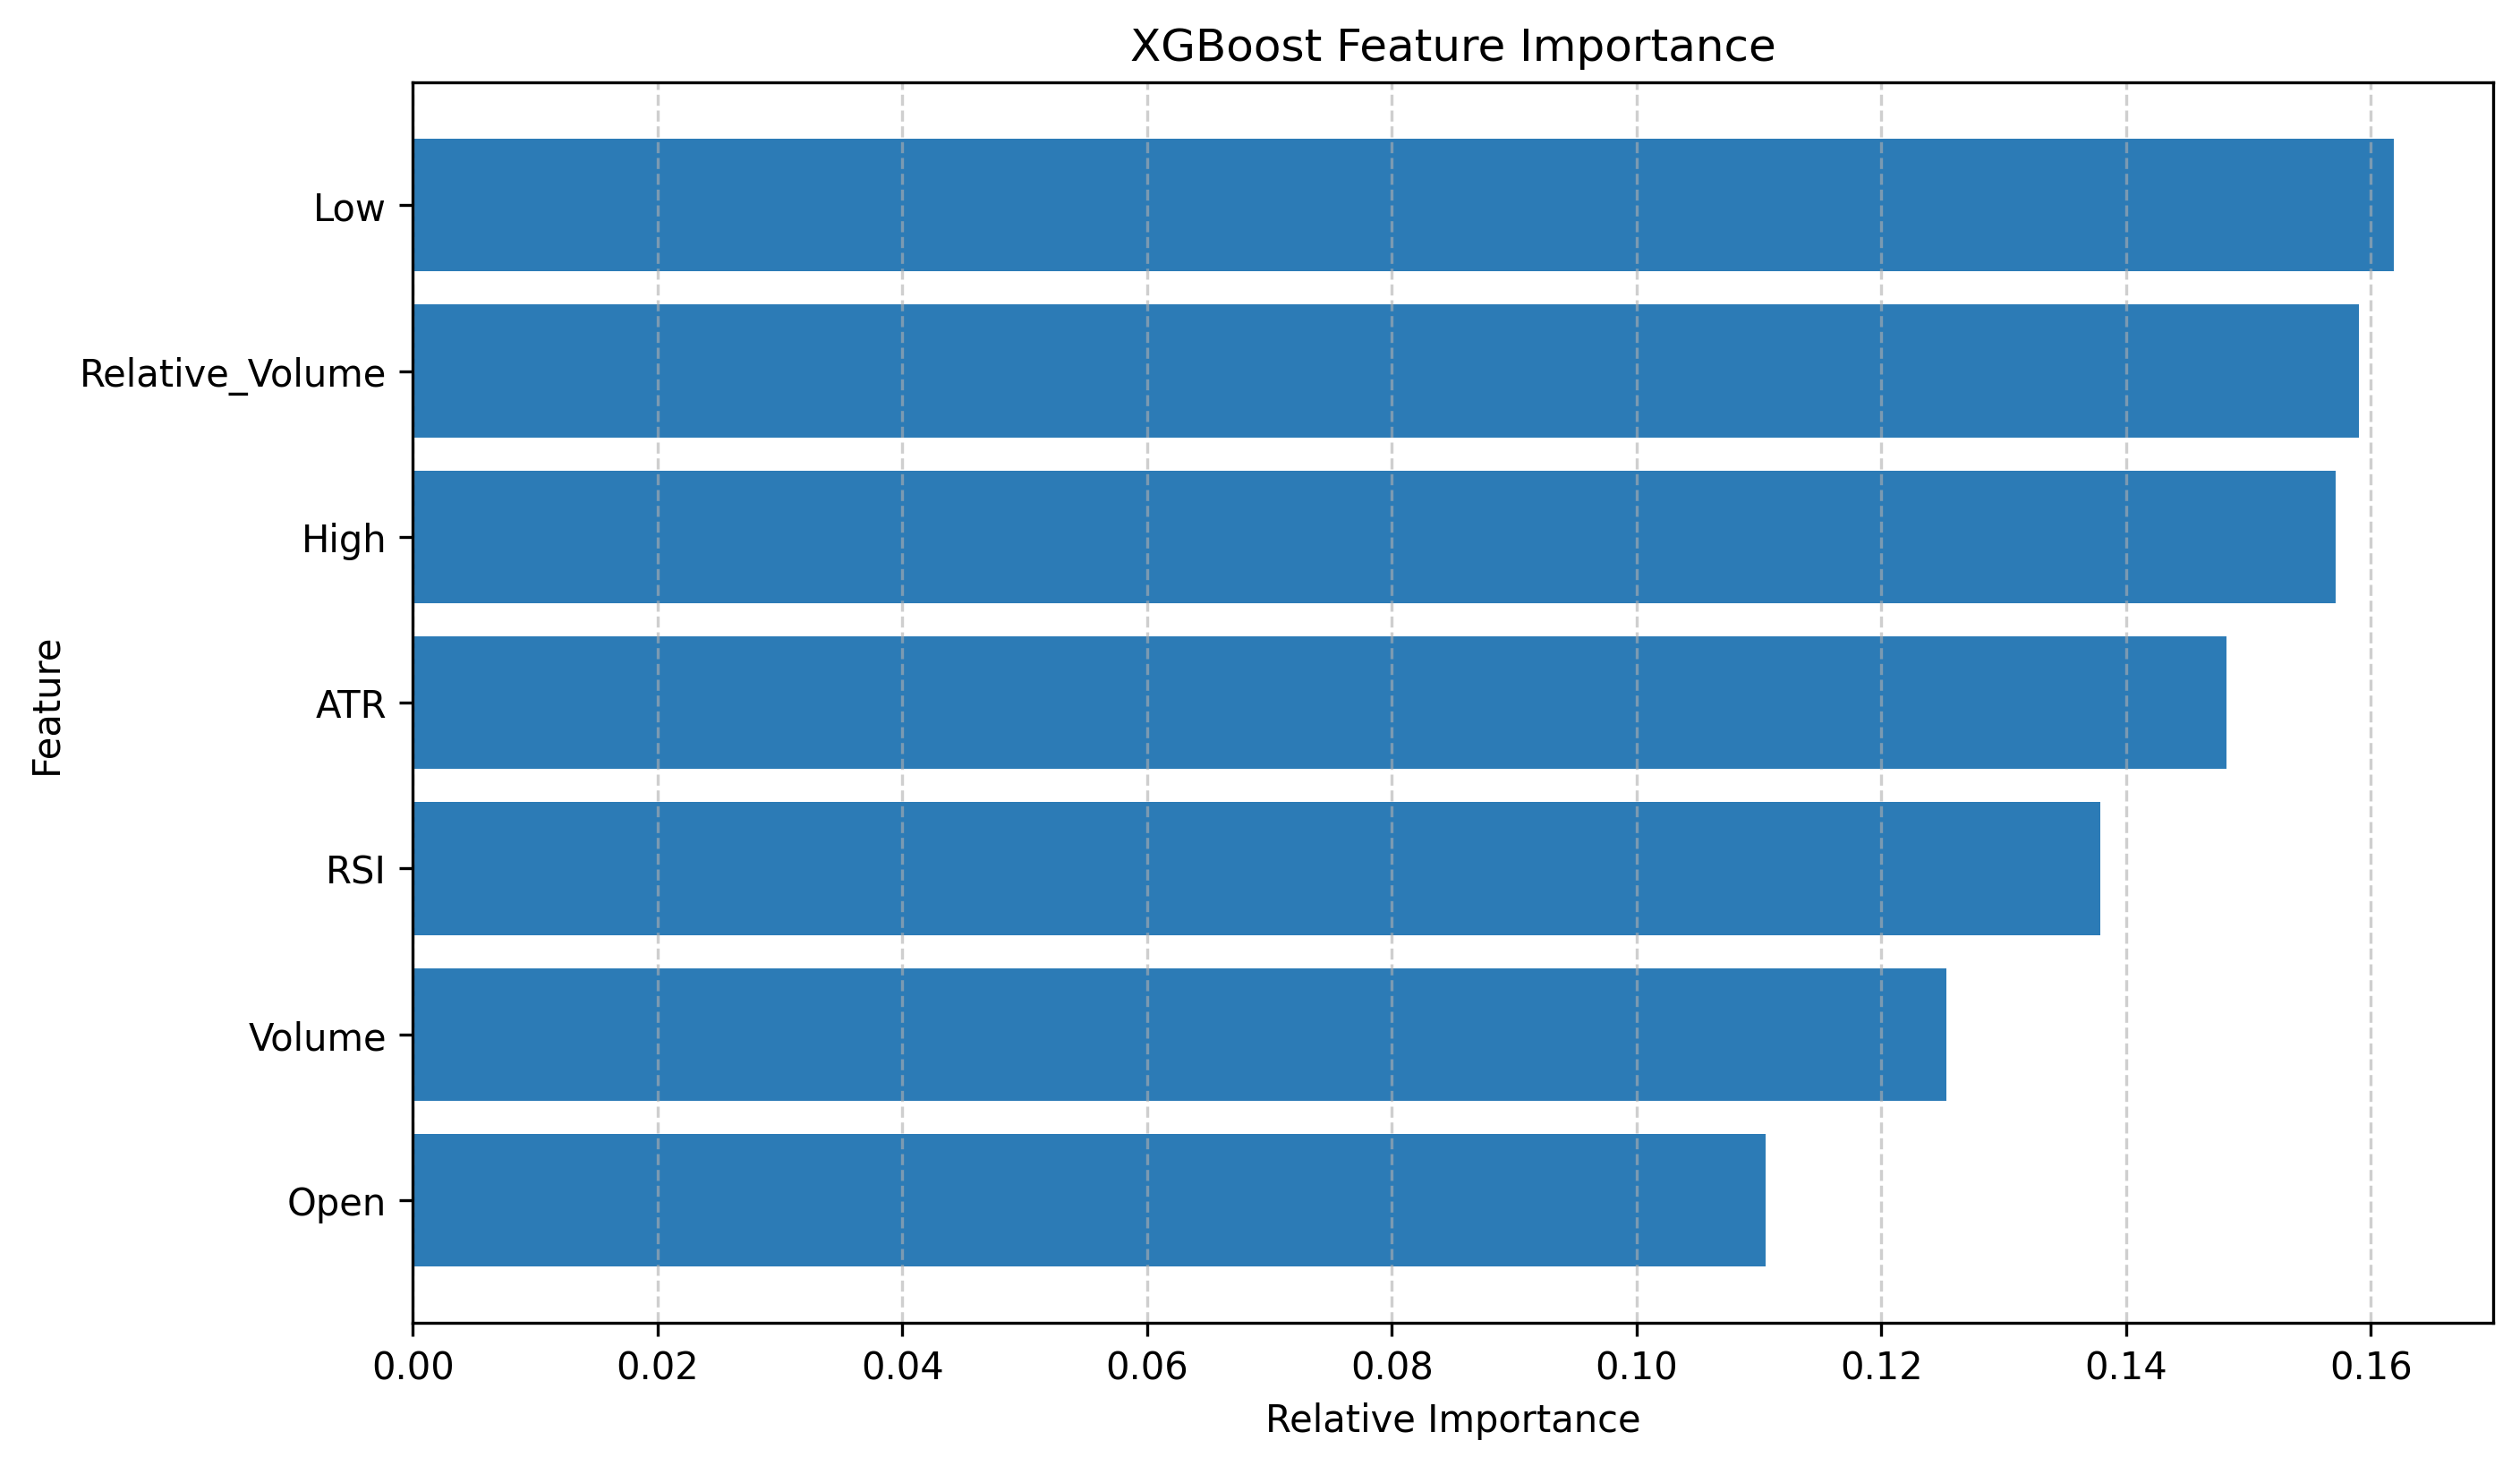


Generating Figure 2: Out-of-Sample Strategy Performance...


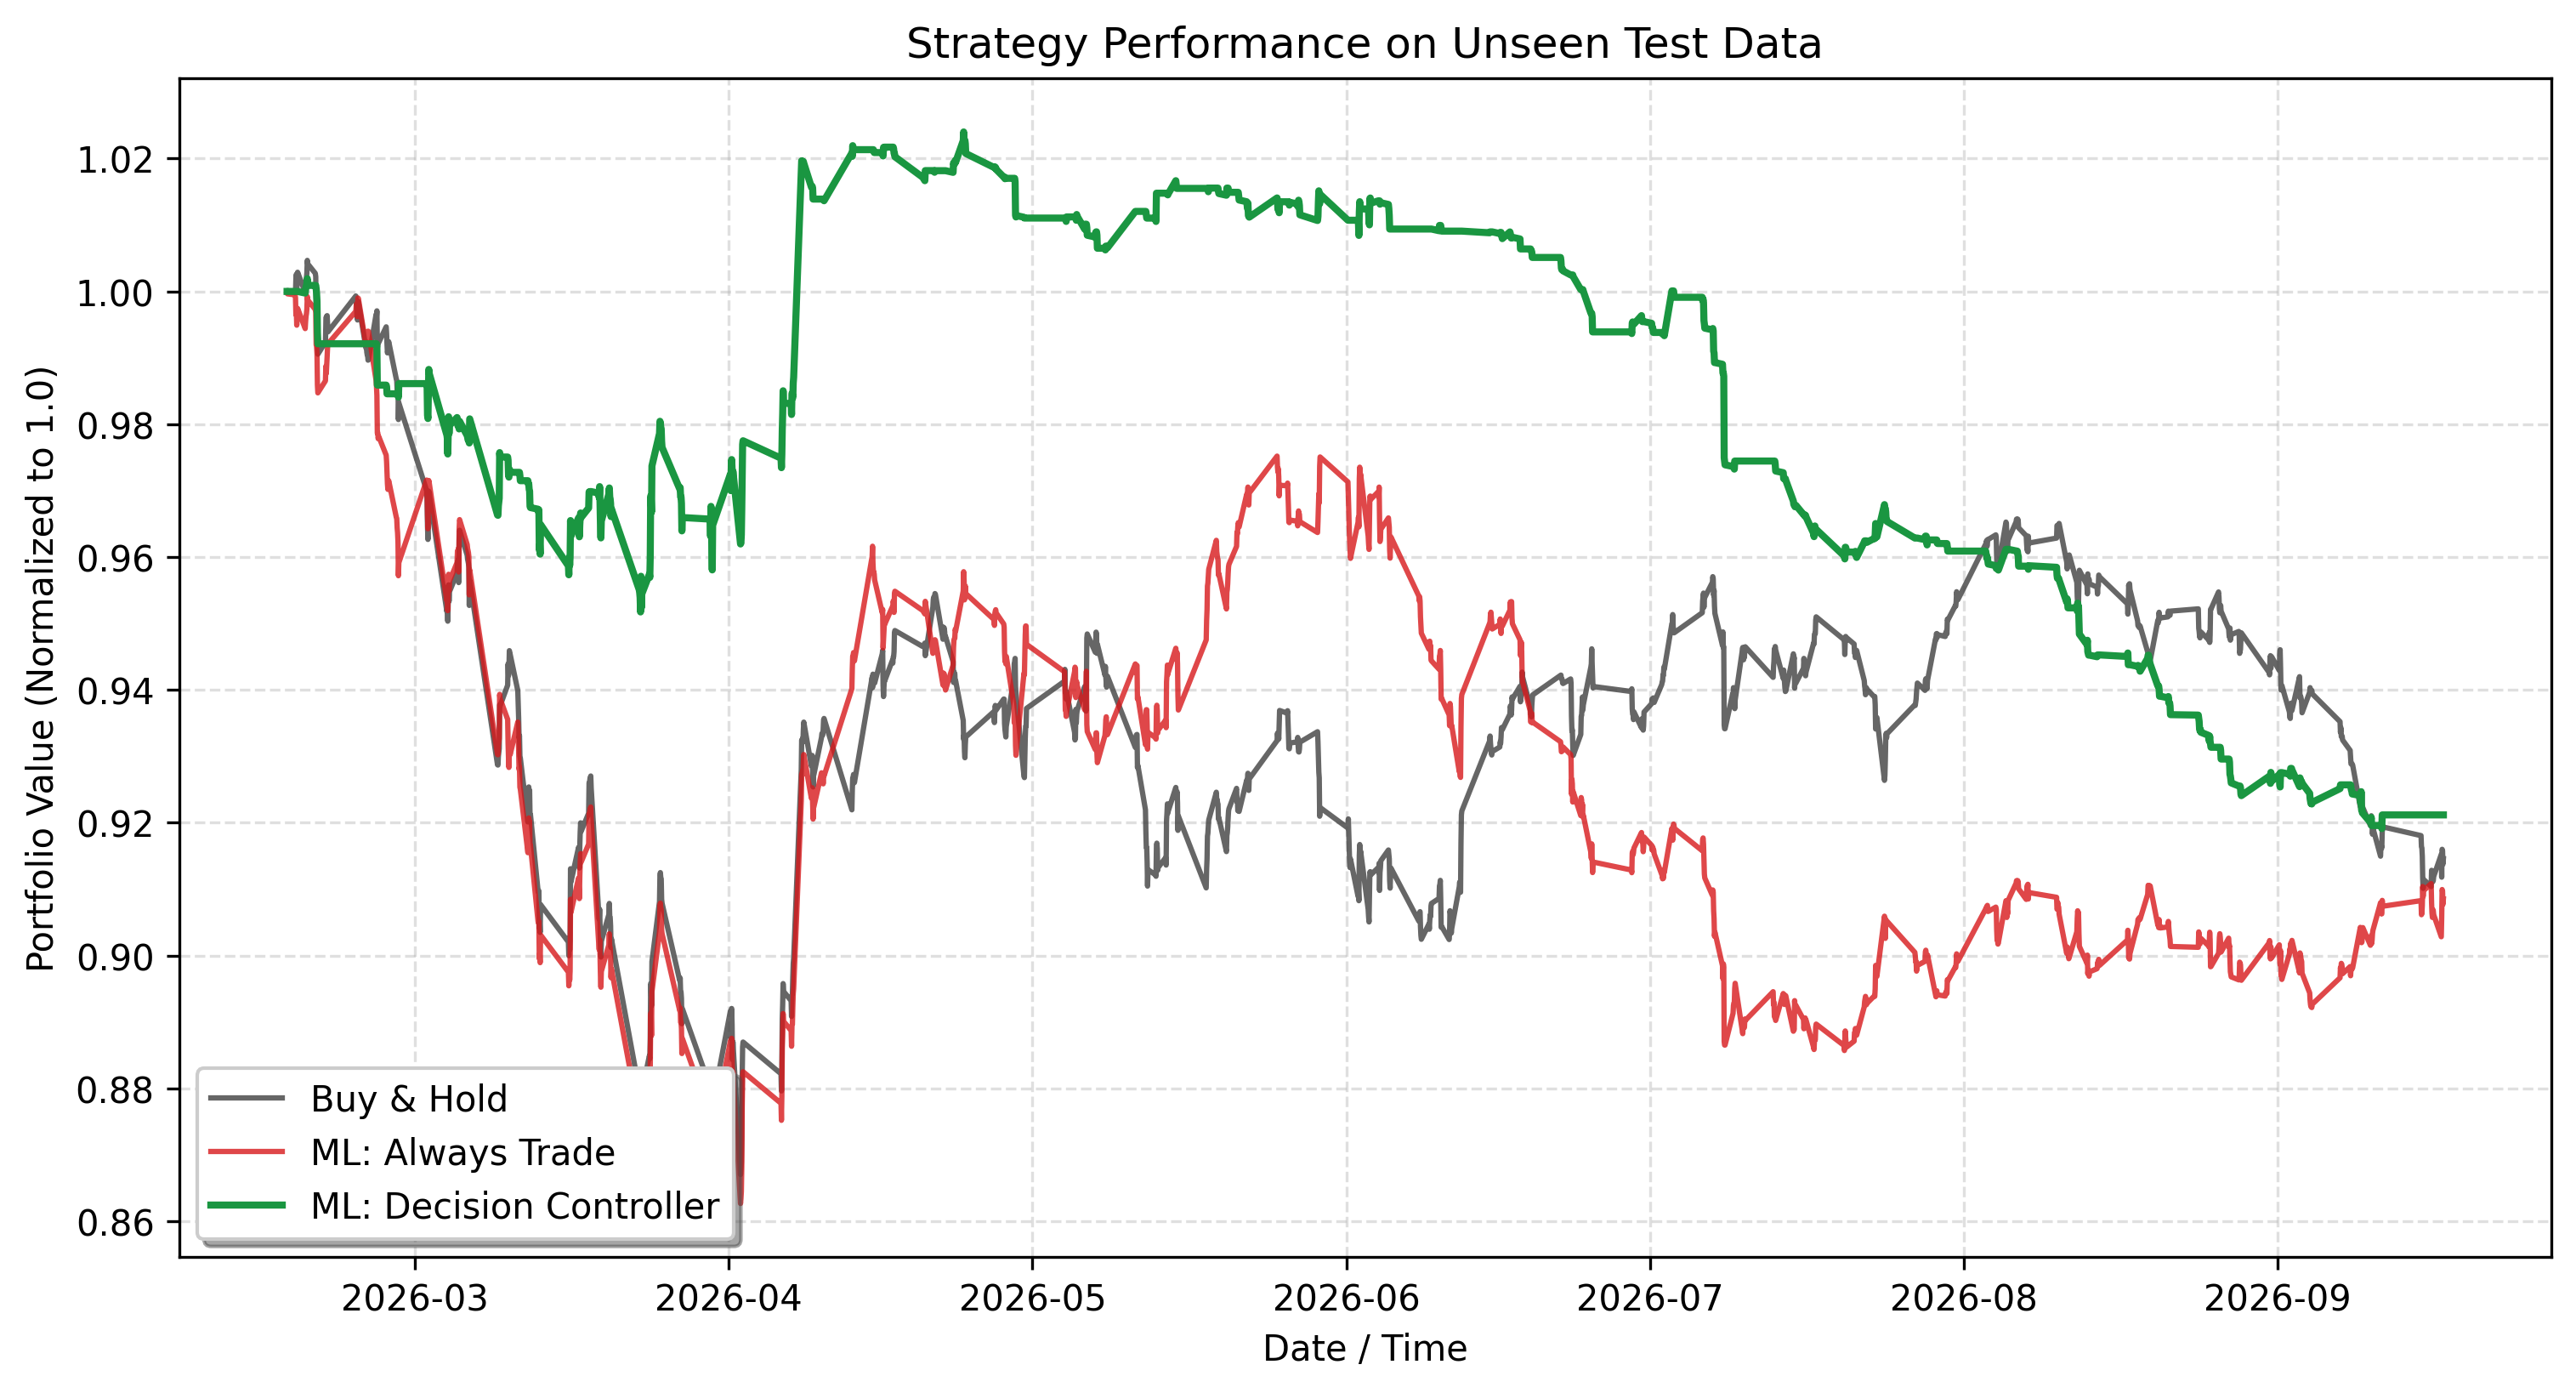


Success! Both charts have been saved as high-resolution PNG files.
Check the folder icon on the left side of Colab to download them!


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================
# 1. PLOT CONFIGURATION
# ============================================================

# Configure high-resolution output for the research paper.
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"


# ============================================================
# 2. FIGURE 1 — XGBOOST FEATURE IMPORTANCE
# ============================================================

print("Generating Figure 1: Feature Importance Bar Chart...")


# Define model features and retrieve their importance scores.
features = [
    "Open",
    "High",
    "Low",
    "Volume",
    "Relative_Volume",
    "ATR",
    "RSI"
]

importances = model.feature_importances_


# Sort features by their importance.
indices = np.argsort(importances)


# Create the feature importance figure.
fig1, ax1 = plt.subplots(figsize=(10, 6))

ax1.barh(
    range(len(indices)),
    importances[indices],
    color="#2c7bb6",
    align="center"
)

ax1.set_yticks(range(len(indices)))
ax1.set_yticklabels(
    [features[i] for i in indices]
)

ax1.set_xlabel("Relative Importance")
ax1.set_ylabel("Feature")
ax1.set_title("XGBoost Feature Importance")

ax1.grid(
    True,
    axis="x",
    linestyle="--",
    alpha=0.6
)


# Save Figure 1 as a high-resolution PNG.
plt.savefig(
    "Figure_1_Feature_Importance.png"
)

plt.show()


# ============================================================
# 3. FIGURE 2 — OUT-OF-SAMPLE STRATEGY PERFORMANCE
# ============================================================

print("\nGenerating Figure 2: Out-of-Sample Strategy Performance...")


# Isolate the final 20% of observations as the
# out-of-sample test dataset.
split_idx = int(len(df) * 0.8)

test_df = df.iloc[split_idx:].copy()


# ------------------------------------------------------------
# 3.1 Normalize Equity Curves
# ------------------------------------------------------------

# Normalize all equity curves so that each starts at 1.0
# at the beginning of the test period.
bh_curve = (
    test_df["B&H_Equity"]
    / test_df["B&H_Equity"].iloc[0]
)

at_curve = (
    test_df["Always_Trade_Equity"]
    / test_df["Always_Trade_Equity"].iloc[0]
)

sys_curve = (
    test_df["System_Equity"]
    / test_df["System_Equity"].iloc[0]
)


# ------------------------------------------------------------
# 3.2 Create Equity Curve Figure
# ------------------------------------------------------------

fig2, ax2 = plt.subplots(figsize=(12, 6))


# Buy & Hold
ax2.plot(
    test_df.index,
    bh_curve,
    label="Buy & Hold",
    color="#404040",
    linewidth=1.5,
    alpha=0.8
)


# ML: Always Trade
ax2.plot(
    test_df.index,
    at_curve,
    label="ML: Always Trade",
    color="#d7191c",
    linewidth=1.5,
    alpha=0.8
)


# ML: Decision Controller
ax2.plot(
    test_df.index,
    sys_curve,
    label="ML: Decision Controller",
    color="#1a9641",
    linewidth=2.0
)


# Chart labels and formatting.
ax2.set_title(
    "Strategy Performance on Unseen Test Data"
)

ax2.set_xlabel("Date / Time")

ax2.set_ylabel(
    "Portfolio Value (Normalized to 1.0)"
)

ax2.legend(
    loc="lower left",
    frameon=True,
    shadow=True
)

ax2.grid(
    True,
    linestyle="--",
    alpha=0.4
)


# Save Figure 2 as a high-resolution PNG.
plt.savefig(
    "Figure_2_Equity_Curve.png"
)

plt.show()


# ============================================================
# 4. COMPLETION MESSAGE
# ============================================================

print(
    "\nSuccess! Both charts have been saved as "
    "high-resolution PNG files."
)

print(
    "Check the folder icon on the left side of Colab "
    "to download them!"
)